<h1>Лабораторна робота No1</h1>
<h2>Робота з зображеннями/ Глобальна Бінаризація</h2>


Мета:
Метою цієї лабораторної роботи є отримання навичок роботи з зображеннями, та
практика методів глобальної бінаризації зображень.

Завантажуємо потрібні нам бібліотекі

In [511]:
import numpy as np
import cv2
from matplotlib import pyplot as plt 

Завантажуємо наші зображення

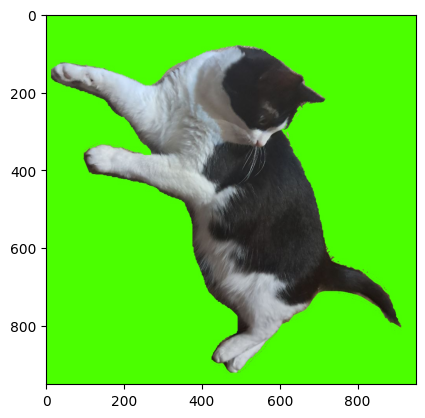

In [512]:
cat_image = cv2.imread('Diva1.jpg')
fon_image = cv2.imread('fon.jpg')
cat_image = cat_image[250:1200, 0:950]
cat_image= cat_image[:, :, ::-1]#робимо це щоб колір картники був нормальним
plt.imshow(cat_image)


Робимо наше зображення cat_image чорно-білим

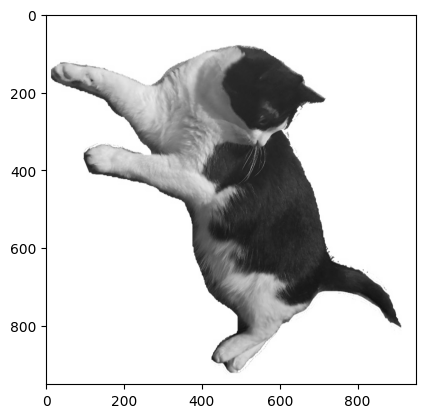

In [513]:
b,cat_image_r,g = cv2.split(cat_image)
all_pixel = 950*950
plt.imshow(cat_image_r, cmap='gray')

Обчислюємо гістограму нашого зображення

In [ ]:
hist_np = np.zeros(256, dtype=int)#заповнюємо нулями
uniq, count = np.unique(cat_image_r, return_counts=True)#виводимо список унікальних значень, та список їх кількості
hist_np[uniq] = count#в списку нашої гістограми, змінюмо ті значення, які входять до unique, на значення з count
print(hist_np)


[     2      2      2      1      3      1      3      1      3      1
      5      6      9     10     13     19     33     43     49     78
    137    170    225    328    632    992   1360   1523   1829   2074
   2289   2492   2801   3073   3874   4517   5389   6598   6460   6804
   6581   5958   5512   4932   4434   3949   3974   3960   3869   3763
   3588   3566   3296   3170   2762   2475   2232   2081   1817   1707
   1581   1400   1411   1273   1303   1089   1053   1029    915    884
    765    787    820    790    807    787    794    810    817    790
    840    869    828    906    869    860    840    815    884    822
    863    819    840    816    797    861    844    966    962    822
    866    900    927    842    863    808    846    838    813    855
    858    881    863    897    966    985    889    949    883    860
    925    928    897    802    881    865    841    827    862    816
    765    815    800    879    785    783    759    784    851    903
    87

Обчислюємо ймовірность кожної яскравості

In [522]:
probability_brightness = hist_np/all_pixel

Сам метод Отсу

In [516]:
max_dis = 0
porog = 0
for t in range(0,256):
    q1=  0
    q2 = 0
    u1 = 0 
    u2 = 0    
    for j in range(0,t):
        q1 += probability_brightness[j]
    for j in range(t,256):
        q2 += probability_brightness[j]
    for k in range(0,t):
        u1 += k*probability_brightness[k]/q1       
    for k in range(t,256):
        u2 += k*probability_brightness[k]/q2
    final_variable = q1*q2*(u1-u2)**2
    if final_variable > max_dis:
        max_dis = final_variable
        porog = t
print("Порог по методу Отсу:", porog)
    
    

Порог по методу Отсу: 159


Фарбуємо наші пікселі, або в чорний, або в білий

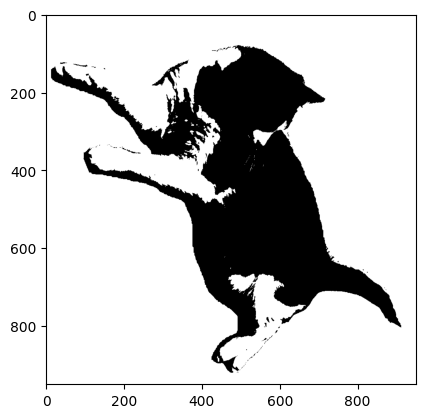

In [517]:
binary_image = np.where(cat_image_r >= porog, 255, 0)
plt.imshow(binary_image, cmap="gray")

Виводимо зображення нашого фону

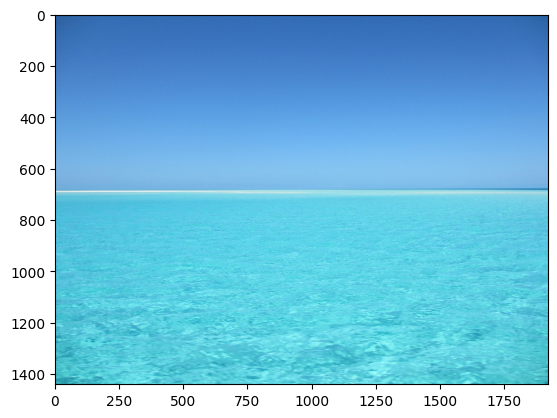

In [519]:
fon_image_normal= fon_image[:, :, ::-1]
plt.imshow(fon_image_normal)

Використовуючи нашу маску, що ми утворили за допомогую методу Отсу, вставляємо наше зображення кішки, на наше тло.

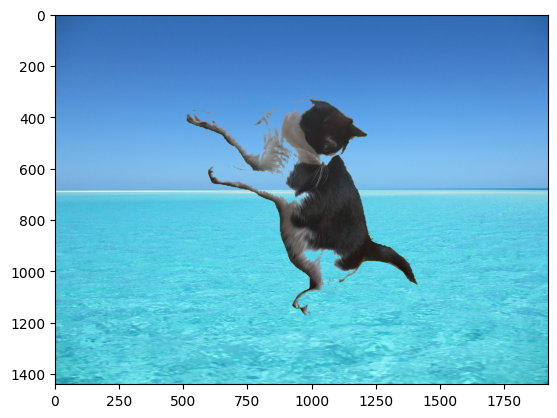

In [ ]:
start_image_y = 250#З якого пікселя починаємо перенос нашого зображення
start_image_x = 500
for i in range(0,950):
    for j in range(0,950):
        if binary_image[i][j] == 0:
            fon_image_normal[i+start_image_y][j+start_image_x] = cat_image [i][j]
plt.imshow(fon_image_normal)